Found 3040 images belonging to 2 classes.
Found 2398 images belonging to 2 classes.
Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.7158 - loss: 0.6532 - val_accuracy: 0.7648 - val_loss: 0.5426
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.7312 - loss: 0.5595 - val_accuracy: 0.7652 - val_loss: 0.5058
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.7441 - loss: 0.5386 - val_accuracy: 0.7748 - val_loss: 0.4868
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.7592 - loss: 0.5176 - val_accuracy: 0.7815 - val_loss: 0.4649
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.7556 - loss: 0.5087 - val_accuracy: 0.7869 - val_loss: 0.4612
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.7664 - loss: 0.4843 - val_accuracy: 0.7932 - val_loss: 0.4303
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.7697 - loss: 0.4801 - val_accuracy: 0.7769 - val_loss: 0.4564
Epoch 8/20
95/95 ━━━━━━━━━━

Model trained successfully!


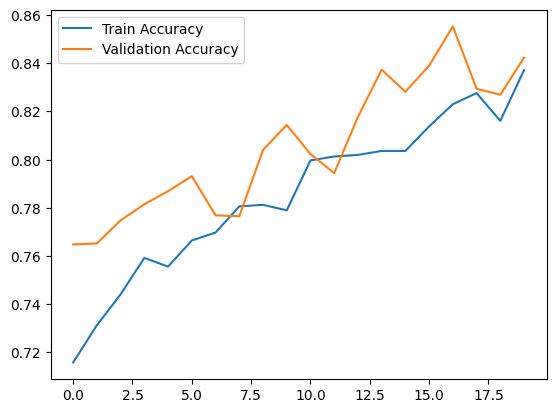

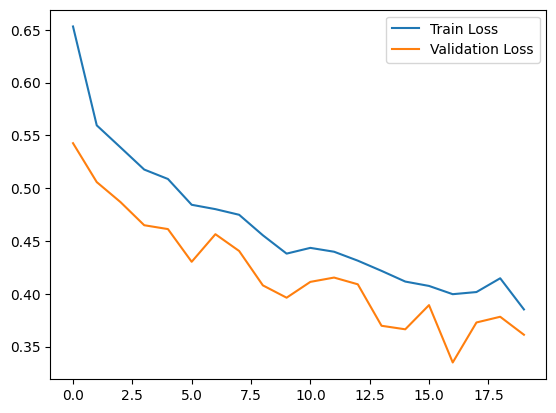

{'fruits': 0, 'vegetables': 1}


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Paths
train_dir = r"C:\Users\Mugilvani\Downloads\archive (1)\train"
val_dir   = r"C:\Users\Mugilvani\Downloads\archive (1)\validation"

img_size = (150, 150)
batch_size = 32

# 🔥 STRONG AUGMENTATION
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    shear_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

# 🔥 IMPORTANT CHANGE: categorical (NOT binary)
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# 🔥 STRONG MODEL
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(2, activation='softmax')   # 🔥 IMPORTANT CHANGE
])

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

# Save model
model.save("fruit_veg_model.h5")

print("Model trained successfully!")

# Accuracy graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

# Loss graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

# 🔥 VERY IMPORTANT
print(train_data.class_indices)